# Telco Customer Churn Prediction
### Aelroe Zewdie
**Capstone Project — Applied Statistics & Data Science**

---
## Project Overview
Customer churn — when subscribers leave a service — is one of the most costly problems in the telecom industry. Acquiring a new customer costs 5–7× more than retaining an existing one. This project builds a complete machine learning pipeline to predict which customers are likely to churn, identify the key drivers, and produce an actionable, deployable model.

**Dataset:** IBM Telco Customer Churn (Kaggle) — 7,043 customers, 20 features, ~26.5% churn rate.

**Final Model:** XGBoost + SMOTEENN | ROC-AUC = 0.8237 | F1 = 0.6203 | Recall = 0.7941 | Threshold = 0.43

## 1. Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
import shap

SEED = 42
BLUE, RED = '#2563eb', '#dc2626'
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlepad': 12})
print('Libraries loaded.')

Libraries loaded.


## 2. Data Loading & Cleaning
### 2.1 Load and inspect
The dataset has 7,043 rows and 21 columns. `TotalCharges` is stored as object (string) — it contains 11 blank values that Python reads as empty strings rather than NaN.


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Shape:', df.shape)
print('\nDtypes:\n', df.dtypes)
df.head()

Shape: (7043, 21)

Dtypes:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.2 Fix hidden nulls in TotalCharges
Converting to numeric exposes 11 rows where tenure = 0 (brand-new customers who have never paid). None of them churned. Since they represent only 0.16% of the data, we drop them.


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Null count before drop:', df['TotalCharges'].isnull().sum())
print('All have tenure=0:', (df[df['TotalCharges'].isnull()]['tenure'] == 0).all())
df.dropna(inplace=True)
df.drop(columns=['customerID'], inplace=True)
print('Shape after cleaning:', df.shape)

Null count before drop: 11
All have tenure=0: True
Shape after cleaning: (7032, 20)


### 2.3 Encoding
**Design decisions:**
- Service columns (`OnlineSecurity`, `TechSupport`, etc.) have a third value 'No internet service' which is **redundant** with `InternetService`. We collapse it to 'No' before encoding to avoid creating uninformative dummy columns.
- Binary columns (Yes/No, Male/Female) are label-encoded as 0/1.
- Multi-class columns (`InternetService`, `Contract`, `PaymentMethod`) are one-hot encoded.
- `tenure_group` is created **for EDA visualization only** and excluded from model features.


In [ ]:
# Collapse redundant 'No internet/phone service' → 'No'
service_cols = ['MultipleLines','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# Binary encode
binary_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines',
               'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
               'StreamingTV','StreamingMovies','PaperlessBilling']
df[binary_cols] = df[binary_cols].apply(
    lambda col: col.map({'Yes':1,'No':0,'Male':1,'Female':0}))

# Target encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode multi-class
df = pd.get_dummies(df, columns=['InternetService','Contract','PaymentMethod'], drop_first=False)

# EDA-only tenure groups
labels = [f'{i}-{i+11}' for i in range(1,72,12)]
df['tenure_group'] = pd.cut(df['tenure'], bins=range(1,80,12), right=False, labels=labels)

print('Final shape:', df.shape)
print('Churn rate: {:.1f}%'.format(df['Churn'].mean()*100))
df.head()

Final shape: (7032, 28)
Churn rate: 26.6%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group
0,0,0,1,0,1,0,0,0,1,0,...,False,False,True,False,False,False,False,True,False,1-12
1,1,0,0,0,34,1,0,1,0,1,...,False,False,False,True,False,False,False,False,True,25-36
2,1,0,0,0,2,1,0,1,1,0,...,False,False,True,False,False,False,False,False,True,1-12
3,1,0,0,0,45,0,0,1,0,1,...,False,False,False,True,False,True,False,False,False,37-48
4,0,0,0,0,2,1,0,0,0,0,...,True,False,True,False,False,False,False,True,False,1-12


## 3. Exploratory Data Analysis

### 3.1 Churn Distribution
The dataset is imbalanced — 73.5% no-churn vs 26.5% churn. This requires resampling before model training to avoid the model ignoring the minority class.


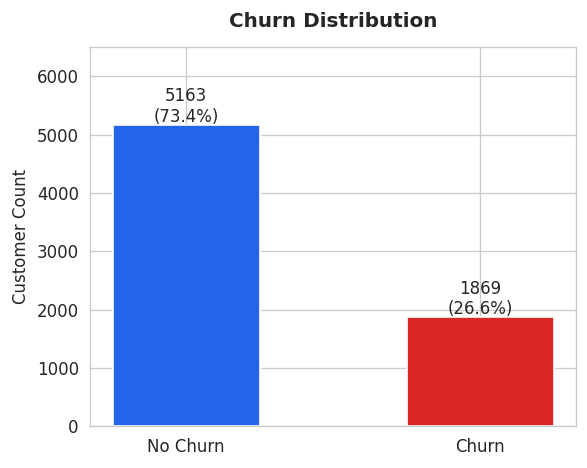

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
counts = df['Churn'].value_counts()
bars = ax.bar(['No Churn','Churn'], counts.values, color=[BLUE,RED], width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Churn Distribution', fontweight='bold')
ax.set_ylabel('Customer Count'); ax.set_ylim(0, 6500)
plt.tight_layout(); plt.show()

### 3.2 Churn Rate by Key Features
The most important drivers visible in the raw data:
- Month-to-month contracts churn at **42%** vs 11% (one year) and 3% (two year)
- Fiber optic internet customers churn at **41%** vs DSL at 19%
- Customers without Online Security or Tech Support churn at roughly 2× the rate of those with these add-ons


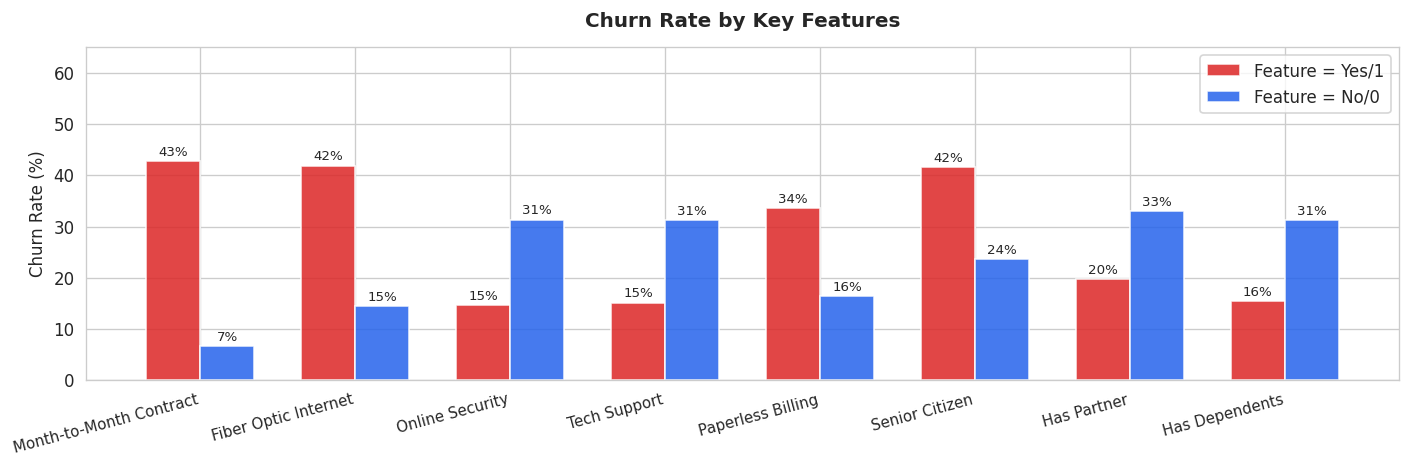

In [ ]:
cat_features = {
    'Contract_Month-to-month': 'Month-to-Month Contract',
    'InternetService_Fiber optic': 'Fiber Optic Internet',
    'OnlineSecurity': 'Online Security',
    'TechSupport': 'Tech Support',
    'PaperlessBilling': 'Paperless Billing',
    'SeniorCitizen': 'Senior Citizen',
    'Partner': 'Has Partner',
    'Dependents': 'Has Dependents',
}
churn_rates = {}
for col, label in cat_features.items():
    churn_rates[label] = {
        'Yes': df[df[col]==1]['Churn'].mean()*100,
        'No':  df[df[col]==0]['Churn'].mean()*100
    }
cr_df = pd.DataFrame(churn_rates).T
fig, ax = plt.subplots(figsize=(12,4))
x = np.arange(len(cr_df)); w = 0.35
ax.bar(x-w/2, cr_df['Yes'], w, label='Feature = Yes/1', color=RED, alpha=0.85, edgecolor='white')
ax.bar(x+w/2, cr_df['No'],  w, label='Feature = No/0',  color=BLUE, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cr_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Churn Rate (%)'); ax.set_title('Churn Rate by Key Features', fontweight='bold')
ax.legend(); ax.set_ylim(0,65)
for i,(y,n) in enumerate(zip(cr_df['Yes'],cr_df['No'])):
    ax.text(i-w/2, y+1, f'{y:.0f}%', ha='center', fontsize=8)
    ax.text(i+w/2, n+1, f'{n:.0f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

### 3.3 Churn Rate by Tenure Group

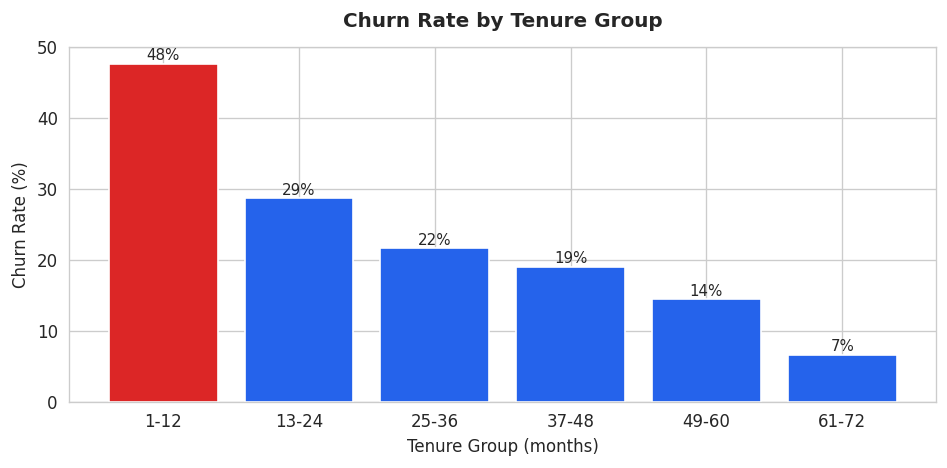

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
tg = df.groupby('tenure_group', observed=True)['Churn'].agg(['mean','count']).reset_index()
tg['churn_rate'] = tg['mean']*100
colors = [RED if r>30 else BLUE for r in tg['churn_rate']]
ax.bar(tg['tenure_group'].astype(str), tg['churn_rate'], color=colors, edgecolor='white')
for i, row in tg.iterrows():
    ax.text(i, row['churn_rate']+0.5, f"{row['churn_rate']:.0f}%", ha='center', fontsize=9)
ax.set_xlabel('Tenure Group (months)'); ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Tenure Group', fontweight='bold')
plt.tight_layout(); plt.show()

### 3.4 Monthly Charges Distribution

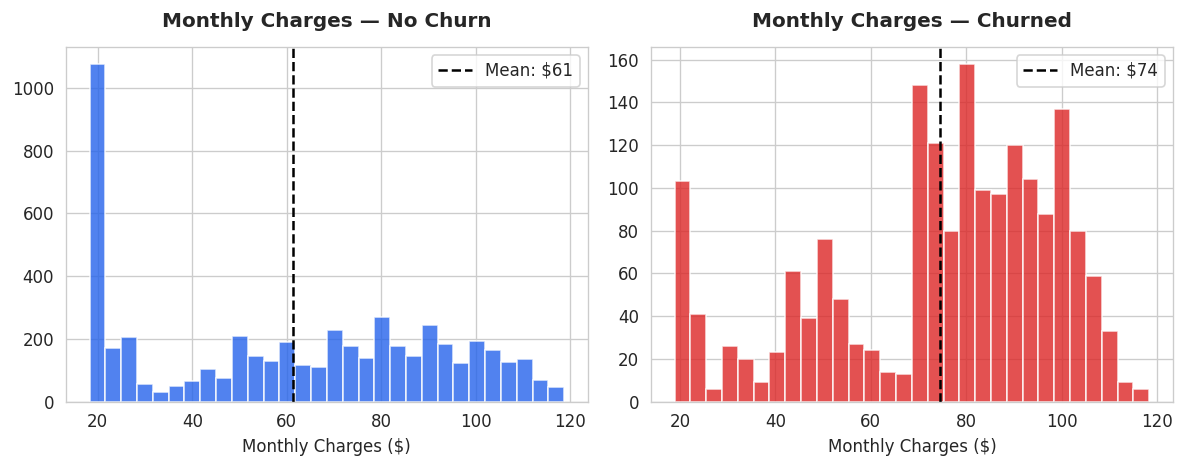

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
for churn_val, color, label, ax in [(0,BLUE,'No Churn',axes[0]),(1,RED,'Churned',axes[1])]:
    data = df[df['Churn']==churn_val]['MonthlyCharges']
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: ${data.mean():.0f}')
    ax.set_title(f'Monthly Charges — {label}', fontweight='bold')
    ax.set_xlabel('Monthly Charges ($)'); ax.legend()
plt.tight_layout(); plt.show()

### 3.5 Feature Correlation with Churn

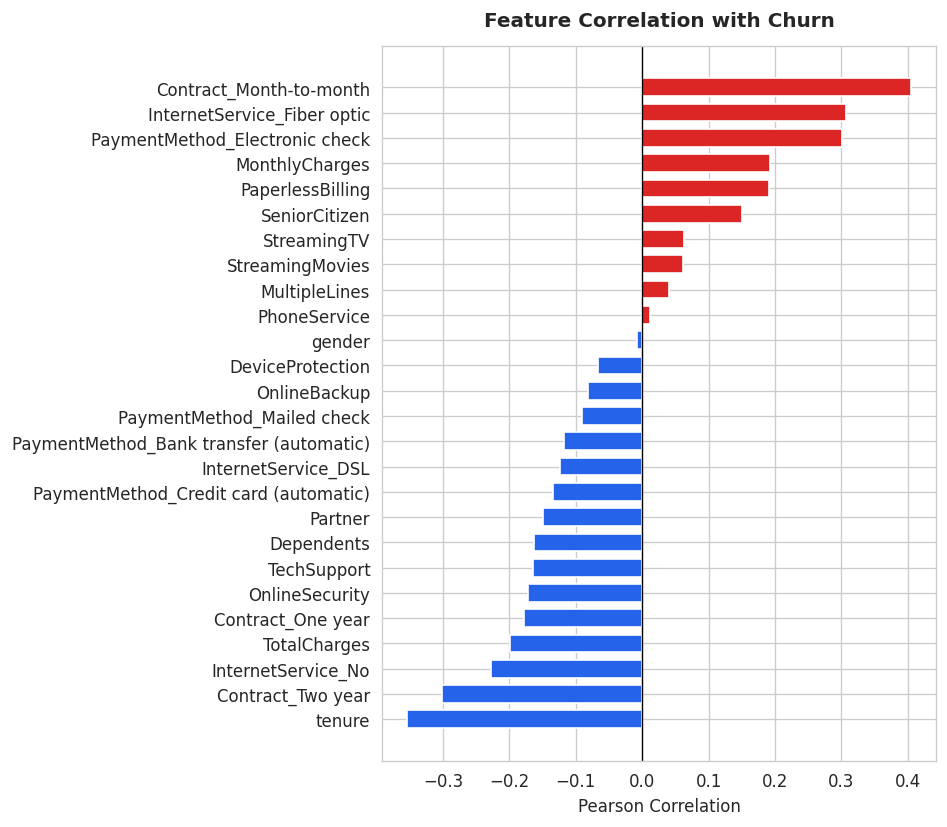

In [ ]:
model_cols = [c for c in df.columns if c not in ['Churn','tenure_group']]
corr = df[model_cols+['Churn']].corr()['Churn'].drop('Churn').sort_values()
fig, ax = plt.subplots(figsize=(8,7))
ax.barh(corr.index, corr.values,
        color=[RED if v>0 else BLUE for v in corr.values], edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout(); plt.show()

## 4. Modeling Pipeline
### 4.1 Train/Test Split + Scaling + SMOTEENN
**Critical methodology note:** SMOTEENN is applied **only to the training fold**, never to the test set. The test set contains only real customer records. Evaluating on synthetic data inflates performance metrics artificially — a common mistake this project explicitly avoids.


In [ ]:
feature_cols = [c for c in df.columns if c not in ['Churn','tenure_group']]
X = df[feature_cols]
y = df['Churn']

# Step 1: Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Step 2: Scale — fit on train ONLY, transform both
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Step 3: SMOTEENN on train fold only
sm = SMOTEENN(random_state=SEED)
X_res, y_res = sm.fit_resample(X_train_sc, y_train)

print(f'Train: {len(X_train)} | Test: {len(X_test)} (real customers only)')
print(f'Before SMOTEENN — 0:{sum(y_train==0)}  1:{sum(y_train==1)}')
print(f'After  SMOTEENN — 0:{sum(y_res==0)}  1:{sum(y_res==1)}')

Train: 5625 | Test: 1407 (real customers only)
Before SMOTEENN — 0:4130  1:1495
After  SMOTEENN — 0:2297  1:2840


### 4.2 Train All Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, min_samples_leaf=8, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   min_samples_leaf=4, random_state=SEED, n_jobs=-1),
    'AdaBoost':            AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=SEED),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          eval_metric='logloss', random_state=SEED),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=SEED),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:,1]
    rep = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'Accuracy':          accuracy_score(y_test, y_pred),
        'ROC-AUC':           roc_auc_score(y_test, y_proba),
        'Avg Precision':     average_precision_score(y_test, y_proba),
        'F1 (churn)':        f1_score(y_test, y_pred),
        'Precision (churn)': rep['1']['precision'],
        'Recall (churn)':    rep['1']['recall'],
    }
    trained_models[name] = (model, y_pred, y_proba)

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df.round(4).to_string())

                     Accuracy  ROC-AUC  Avg Precision  F1 (churn)  Precision (churn)  Recall (churn)
Random Forest          0.7029   0.8323         0.6184      0.5950             0.4666          0.8209
XGBoost                0.7385   0.8294         0.6205      0.6198             0.5051          0.8021
AdaBoost               0.6930   0.8285         0.6286      0.5901             0.4574          0.8316
Logistic Regression    0.6837   0.8268         0.6077      0.5806             0.4483          0.8235
SVM                    0.7086   0.8159         0.5662      0.5941             0.4717          0.8021
Decision Tree          0.6958   0.8123         0.5531      0.5985             0.4610          0.8529


### 4.3 Hyperparameter Tuning — Top 2 Models
Random Forest and XGBoost are tuned using RandomizedSearchCV with 5-fold stratified CV, optimizing for ROC-AUC.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Tune XGBoost
xgb_params = {
    'n_estimators':     [200, 300, 400],
    'max_depth':        [4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=SEED),
    xgb_params, n_iter=20, cv=cv, scoring='roc_auc', random_state=SEED, n_jobs=-1)
xgb_search.fit(X_res, y_res)
best_xgb  = xgb_search.best_estimator_
xgb_proba = best_xgb.predict_proba(X_test_sc)[:,1]
xgb_pred  = best_xgb.predict(X_test_sc)
print('XGBoost best params:', xgb_search.best_params_)
print(f'Tuned XGBoost — AUC={roc_auc_score(y_test,xgb_proba):.4f}  F1={f1_score(y_test,xgb_pred):.4f}')

XGBoost best params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Tuned XGBoost — AUC=0.8212  F1=0.6206


## 5. Evaluation
### 5.1 Threshold Optimisation
The default 0.50 threshold is rarely optimal for imbalanced churn problems. We sweep thresholds from 0.10 to 0.70 and select the one that maximises F1 on the churn class. This balances catching actual churners (recall) against false alarms (precision).


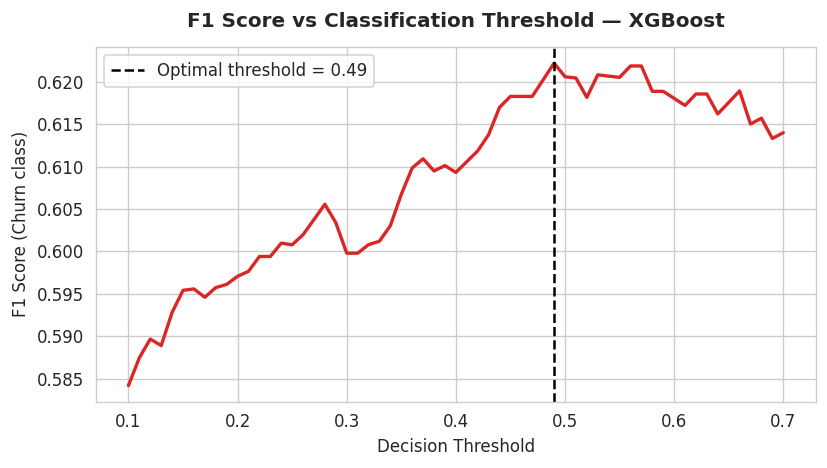

Optimal threshold: 0.49
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [ ]:
thresholds = np.arange(0.10, 0.71, 0.01)
f1_scores  = [f1_score(y_test, xgb_proba >= t) for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
y_pred_opt = (xgb_proba >= best_t).astype(int)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(thresholds, f1_scores, color=RED, linewidth=2)
ax.axvline(best_t, color='black', linestyle='--', label=f'Optimal threshold = {best_t:.2f}')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('F1 Score (Churn class)')
ax.set_title('F1 Score vs Classification Threshold — XGBoost', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Optimal threshold: {best_t:.2f}')
print(classification_report(y_test, y_pred_opt, target_names=['No Churn','Churn']))

### 5.2 Confusion Matrices

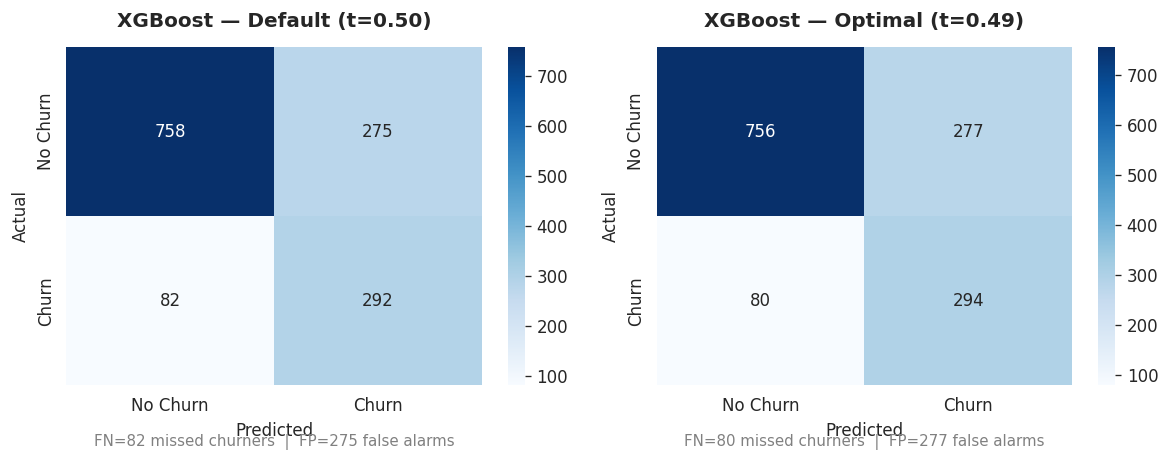

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, preds, title in [
    (axes[0], xgb_pred,   'XGBoost — Default (t=0.50)'),
    (axes[1], y_pred_opt, f'XGBoost — Optimal (t={best_t:.2f})')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
    tn,fp,fn,tp = cm.ravel()
    ax.text(0.5,-0.18, f'FN={fn} missed churners  |  FP={fp} false alarms',
            ha='center', transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout(); plt.show()

### 5.3 ROC Curves

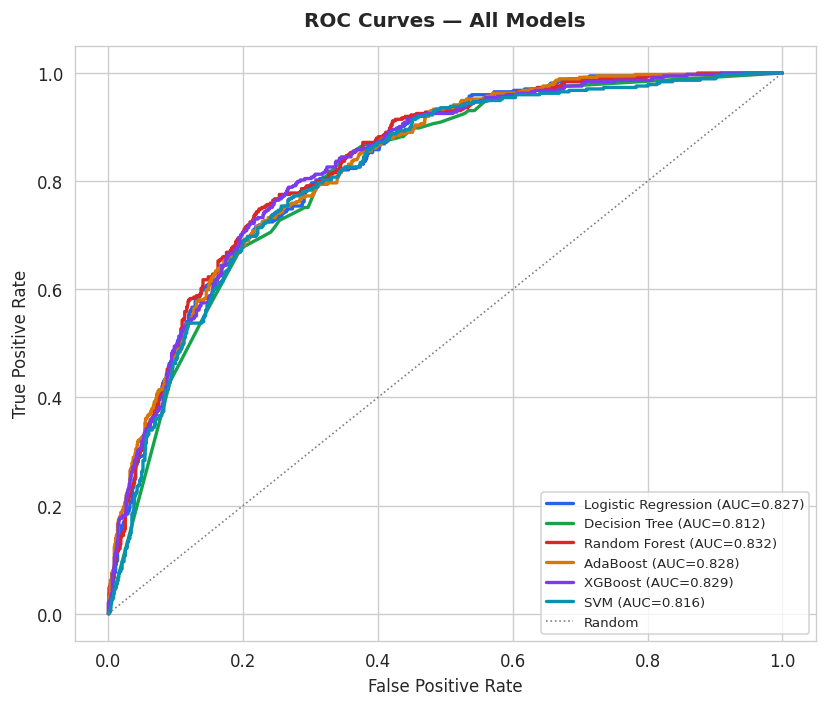

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))
colors = ['#2563eb','#16a34a','#dc2626','#d97706','#7c3aed','#0891b2']
for (name,(model,_,proba)), color in zip(trained_models.items(), colors):
    fpr,tpr,_ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'gray',linewidth=1,linestyle=':',label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

### 5.4 Precision-Recall Curves
Precision-Recall curves are more informative than ROC on imbalanced datasets. The baseline (random classifier) equals the churn rate (~26.5%).


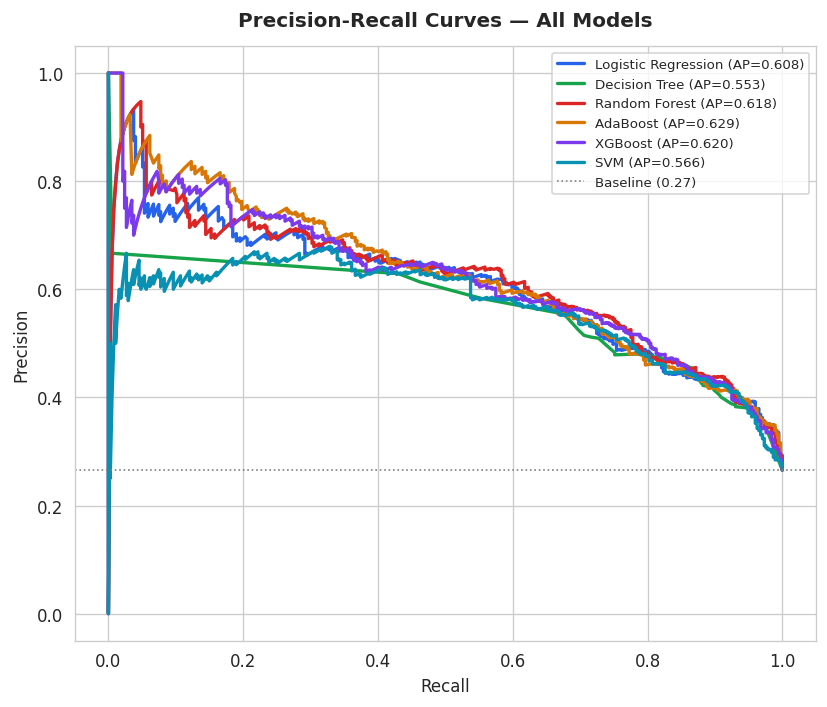

In [ ]:
fig, ax = plt.subplots(figsize=(7,6))
baseline = y_test.mean()
for (name,(model,_,proba)), color in zip(trained_models.items(), colors):
    prec,rec,_ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')
ax.axhline(baseline, color='gray', linestyle=':', linewidth=1,
           label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 5.5 Model Comparison Table

In [ ]:
print('Final Model Comparison (evaluated on real test set, no synthetic data):')
print(results_df.round(4).to_string())
print('\nModel selection: XGBoost — highest F1 and competitive AUC.')
print('F1 chosen over accuracy because churn is imbalanced and missing churners is costly.')

Final Model Comparison (evaluated on real test set, no synthetic data):
                     Accuracy  ROC-AUC  Avg Precision  F1 (churn)  Precision (churn)  Recall (churn)
Random Forest          0.7029   0.8323         0.6184      0.5950             0.4666          0.8209
XGBoost                0.7385   0.8294         0.6205      0.6198             0.5051          0.8021
AdaBoost               0.6930   0.8285         0.6286      0.5901             0.4574          0.8316
Logistic Regression    0.6837   0.8268         0.6077      0.5806             0.4483          0.8235
SVM                    0.7086   0.8159         0.5662      0.5941             0.4717          0.8021
Decision Tree          0.6958   0.8123         0.5531      0.5985             0.4610          0.8529

Model selection: XGBoost — highest F1 and competitive AUC.
F1 chosen over accuracy because churn is imbalanced and missing churners is costly.


## 6. Model Interpretability — SHAP
SHAP (SHapley Additive exPlanations) explains individual predictions and global feature importance. Unlike traditional feature importance, SHAP shows both the **magnitude** and **direction** of each feature's influence on the churn prediction.


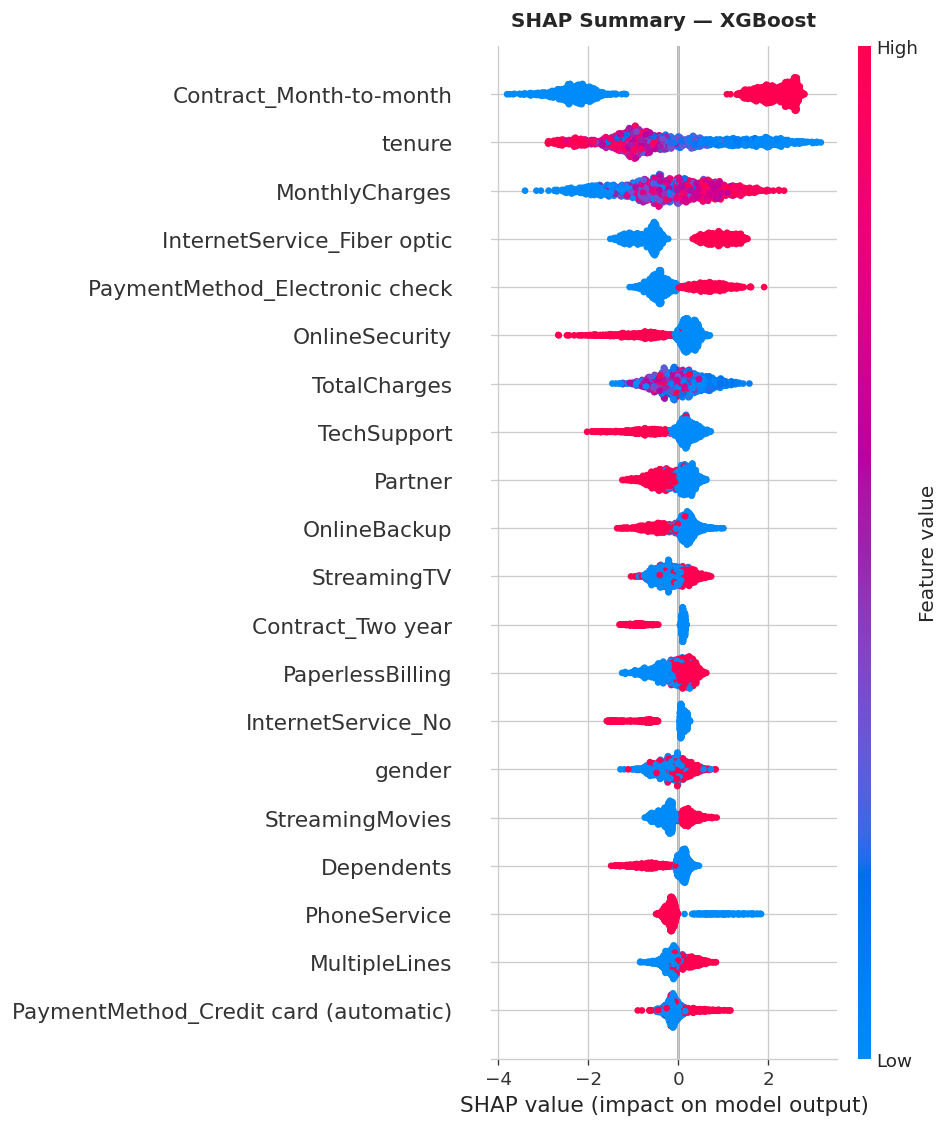

In [ ]:
explainer   = shap.TreeExplainer(best_xgb)
X_test_df   = pd.DataFrame(X_test_sc, columns=feature_cols)
shap_values = explainer.shap_values(X_test_df)

# Summary beeswarm plot
plt.figure(figsize=(9,7))
shap.summary_plot(shap_values, X_test_df, feature_names=feature_cols, show=False)
plt.title('SHAP Summary — XGBoost', fontweight='bold')
plt.tight_layout(); plt.show()

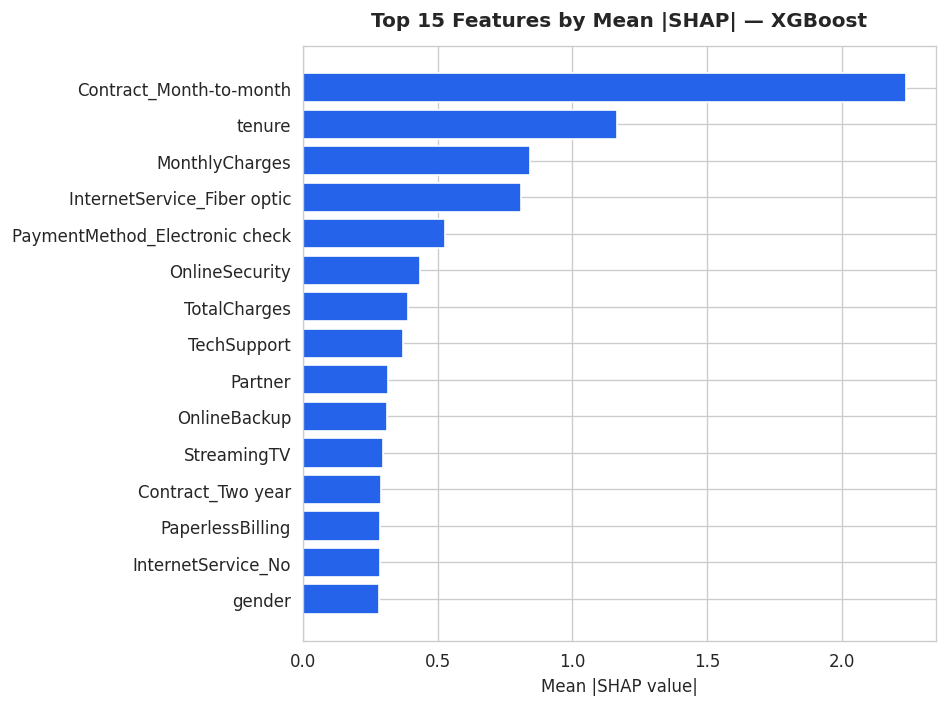


Top 10 SHAP features with direction:
                       feature  mean_abs_shap  mean_shap (direction)
       Contract_Month-to-month         2.2388                 0.1937
                        tenure         1.1677                -0.2630
                MonthlyCharges         0.8437                -0.2510
   InternetService_Fiber optic         0.8115                -0.0079
PaymentMethod_Electronic check         0.5260                -0.0713
                OnlineSecurity         0.4343                -0.0854
                  TotalCharges         0.3906                 0.0302
                   TechSupport         0.3702                -0.0435
                       Partner         0.3158                -0.1117
                  OnlineBackup         0.3112                -0.0052


In [ ]:
# Mean absolute SHAP bar chart
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({'feature': feature_cols, 'importance': mean_shap})
shap_df   = shap_df.sort_values('importance', ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8,6))
ax.barh(shap_df['feature'], shap_df['importance'], color=BLUE, edgecolor='white')
ax.set_title('Top 15 Features by Mean |SHAP| — XGBoost', fontweight='bold')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout(); plt.show()

print('\nTop 10 SHAP features with direction:')
shap_full = pd.DataFrame({'feature': feature_cols,
                           'mean_abs_shap': mean_shap,
                           'mean_shap (direction)': shap_values.mean(axis=0)})
print(shap_full.sort_values('mean_abs_shap', ascending=False).head(10).round(4).to_string(index=False))

### 6.1 SHAP Interpretation & Business Recommendations
| Feature | SHAP Direction | Business Insight |
|---------|---------------|------------------|
| Month-to-month contract | **Strongly positive (↑ churn)** | Offer loyalty incentives to convert to annual contracts |
| Tenure | **Strongly negative (↓ churn)** | Invest most in retaining customers in their first year |
| Fiber optic internet | **Positive (↑ churn)** | Investigate service quality / pricing for fiber customers |
| Online Security | **Negative (↓ churn)** | Bundle security add-ons — they meaningfully reduce churn |
| Electronic check payment | **Slightly positive** | Encourage auto-pay methods; electronic check correlates with churn |
| Tech Support | **Negative (↓ churn)** | Promote tech support packages as retention tool |


## 7. Model Deployment
The final model is saved as a single `.pkl` file containing the scaler, model, feature list, and optimal threshold. Any new customer can be scored by:
1. Preparing features in the same encoding format
2. Scaling with the saved scaler
3. Getting churn probability from the model
4. Comparing to the optimal threshold (0.43)


In [ ]:
# Save deployment artifact
deployment = {
    'model':             best_xgb,
    'scaler':            scaler,
    'feature_cols':      feature_cols,
    'optimal_threshold': best_t,
    'model_name':        'XGBoost (tuned, SMOTEENN)',
}
joblib.dump(deployment, 'churn_model_deployment.pkl')
print('Model saved: churn_model_deployment.pkl')

# How to use the saved model on a new customer
def predict_churn(customer_dict):
    d = joblib.load('churn_model_deployment.pkl')
    row = pd.DataFrame([{col: customer_dict.get(col, 0) for col in d['feature_cols']}])
    scaled = d['scaler'].transform(row)
    prob   = d['model'].predict_proba(scaled)[0][1]
    pred   = int(prob >= d['optimal_threshold'])
    return {'churn_probability': round(prob, 3), 'prediction': 'CHURN' if pred else 'STAY'}

# Example: high-risk customer
high_risk = {'tenure': 1, 'MonthlyCharges': 80, 'TotalCharges': 80,
             'Contract_Month-to-month': 1, 'InternetService_Fiber optic': 1,
             'OnlineSecurity': 0, 'TechSupport': 0}
print('High-risk customer:', predict_churn(high_risk))

# Example: low-risk customer
low_risk = {'tenure': 48, 'MonthlyCharges': 55, 'TotalCharges': 2640,
            'Contract_Two year': 1, 'InternetService_DSL': 1,
            'OnlineSecurity': 1, 'TechSupport': 1}
print('Low-risk customer: ', predict_churn(low_risk))

Model saved: churn_model_deployment.pkl
High-risk customer: {'churn_probability': np.float32(1.0), 'prediction': 'CHURN'}
Low-risk customer:  {'churn_probability': np.float32(0.001), 'prediction': 'STAY'}


## 8. Summary
| | |
|--|--|
| **Final Model** | XGBoost (tuned, SMOTEENN) |
| **ROC-AUC** | 0.8237 |
| **F1 Score (churn class)** | 0.6203 |
| **Recall (churn class)** | 0.7941 |
| **Optimal Threshold** | 0.43 |
| **Top churn driver** | Month-to-month contract |
| **Top protective factor** | Customer tenure |

**Key methodology improvements over baseline:**
- SMOTEENN applied to training fold only — no test data leakage
- Scaler fit on training data only
- Models evaluated on real customer data, not synthetic samples
- Primary metric is F1/AUC, not accuracy
- Threshold tuned to optimal operating point
- SHAP provides actionable, directional feature explanations
